# Sephora Product Intelligence — Ingredient Analysis

## Purpose
A dedicated deep dive into how ingredient quality relates to product ratings,
price, and customer satisfaction. Rather than relying on feature importance
from the ML model, we directly measure ingredient impact using correlation
analysis, group comparisons, and specific ingredient breakdowns.

## Business questions answered here:
- Do products with better ingredients actually rate higher?
- Which specific ingredients appear most in highly rated products?
- Do powerhouse products outperform non-powerhouse?
- Which categories have the best ingredient profiles?
- Is there a relationship between ingredient quality and price?

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries loaded")

Libraries loaded


## 2. Load Feature Dataset
We load the full feature dataset which includes all engineered 
ingredient features alongside ratings and price data.

In [9]:
df = pd.read_csv("../data/processed/features_ml.csv")

# Load ingredients from cleaned products and merge in
products_clean = pd.read_csv("../data/processed/products_clean.csv")
df = df.merge(products_clean[["product_id", "ingredients"]], 
              on="product_id", how="left")

print(f"Dataset shape: {df.shape}")
print(f"Products with ingredient data: {df['ingredient_score'].notna().sum()}")
print(f"Products with raw ingredients text: {df['ingredients'].notna().sum()}")
print(f"\nIngredient score distribution:")
print(df["ingredient_score"].describe())

Dataset shape: (1915, 29)
Products with ingredient data: 1915
Products with raw ingredients text: 1875

Ingredient score distribution:
count   1915.000
mean       0.097
std        0.092
min       -0.294
25%        0.049
50%        0.091
75%        0.136
max        1.500
Name: ingredient_score, dtype: float64


## 3. Ingredient Score vs Rating
Does having better ingredients actually lead to higher ratings?
We directly measure the relationship between ingredient_score and avg_rating.

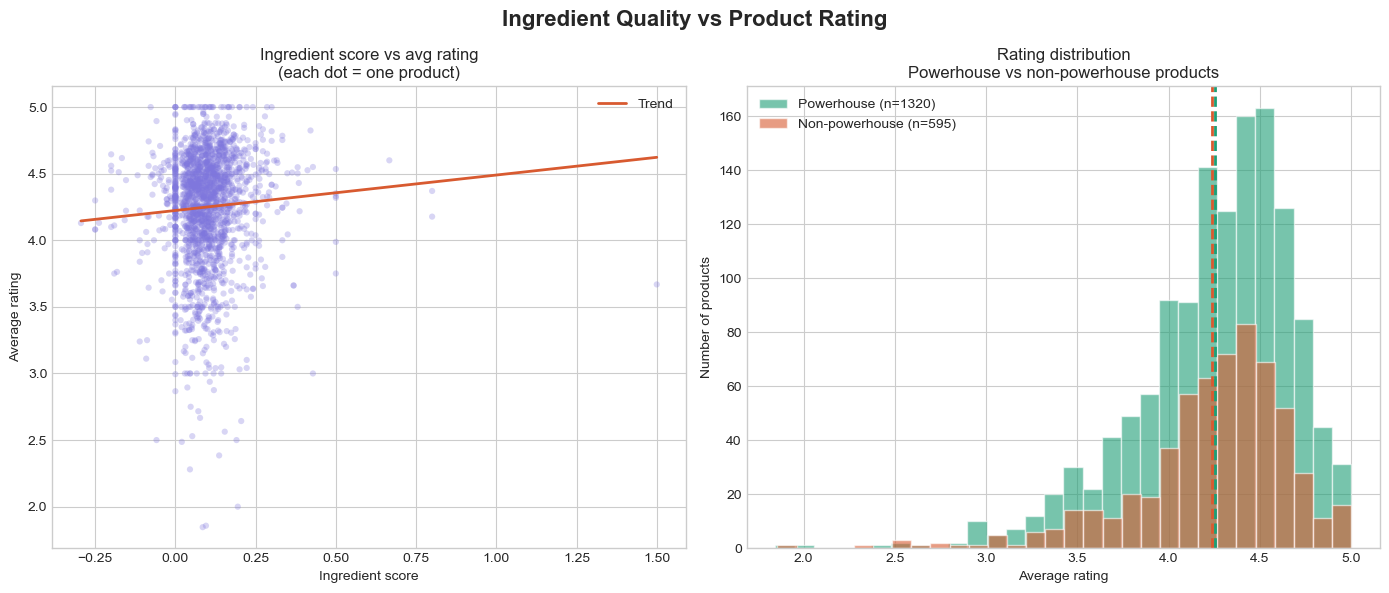

Correlation between ingredient score and avg rating: 0.057

Powerhouse products avg rating: 4.254
Non-powerhouse products avg rating: 4.239
Difference: 0.015


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ingredient Quality vs Product Rating", fontsize=16, fontweight="bold")

# Plot 1: Scatter plot ingredient score vs avg_rating
axes[0].scatter(
    df["ingredient_score"],
    df["avg_rating"],
    alpha=0.3,
    color="#7F77DD",
    edgecolors="none",
    s=20
)

# Trend line
z = np.polyfit(df["ingredient_score"].dropna(), 
               df["avg_rating"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df["ingredient_score"].min(), 
                     df["ingredient_score"].max(), 100)
axes[0].plot(x_line, p(x_line), color="#D85A30", linewidth=2, label="Trend")
axes[0].set_title("Ingredient score vs avg rating\n(each dot = one product)")
axes[0].set_xlabel("Ingredient score")
axes[0].set_ylabel("Average rating")
axes[0].legend()

# Plot 2: Powerhouse vs non-powerhouse rating distribution
powerhouse = df[df["powerhouse_flag"] == 1]["avg_rating"]
non_powerhouse = df[df["powerhouse_flag"] == 0]["avg_rating"]

axes[1].hist(powerhouse, bins=30, alpha=0.6, color="#1D9E75", 
             label=f"Powerhouse (n={len(powerhouse)})", edgecolor="white")
axes[1].hist(non_powerhouse, bins=30, alpha=0.6, color="#D85A30", 
             label=f"Non-powerhouse (n={len(non_powerhouse)})", edgecolor="white")
axes[1].axvline(powerhouse.mean(), color="#1D9E75", linestyle="--", linewidth=2)
axes[1].axvline(non_powerhouse.mean(), color="#D85A30", linestyle="--", linewidth=2)
axes[1].set_title("Rating distribution\nPowerhouse vs non-powerhouse products")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("Number of products")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print correlation
corr = df["ingredient_score"].corr(df["avg_rating"])
print(f"Correlation between ingredient score and avg rating: {corr:.3f}")
print(f"\nPowerhouse products avg rating: {powerhouse.mean():.3f}")
print(f"Non-powerhouse products avg rating: {non_powerhouse.mean():.3f}")
print(f"Difference: {powerhouse.mean() - non_powerhouse.mean():.3f}")

## 4. Specific Ingredient Impact
Which individual ingredients appear most frequently in highly rated products?
We split products into high rated (4.3+) and low rated (below 4.0) and 
compare which ingredients dominate each group.

In [11]:
good_ingredients = [
    "hyaluronic acid", "retinol", "retinyl", "niacinamide", "vitamin c",
    "ascorbic acid", "peptide", "ceramide", "glycerin", "squalane",
    "collagen", "vitamin e", "tocopherol", "salicylic acid", "glycolic acid",
    "lactic acid", "kojic acid", "azelaic acid", "resveratrol", "ferulic acid",
    "zinc", "allantoin", "panthenol", "centella", "madecassoside",
    "tranexamic acid", "arbutin", "adenosine", "bakuchiol", "coenzyme q10",
    "ubiquinone", "green tea", "epigallocatechin", "caffeine", "licorice",
    "aloe vera", "aloe barbadensis", "jojoba", "rosehip", "sea buckthorn",
    "vitamin b3", "vitamin b5", "alpha arbutin", "lipo hydroxy acid",
    "phytic acid", "mandelic acid"
]

# Split into high and low rated
high_rated = df[df["avg_rating"] >= 4.3]["ingredients"].dropna()
low_rated = df[df["avg_rating"] < 4.0]["ingredients"].dropna()

def ingredient_frequency(ingredient_series, ingredient_list):
    freq = {}
    total = len(ingredient_series)
    for ingredient in ingredient_list:
        count = ingredient_series.str.lower().str.contains(ingredient).sum()
        freq[ingredient] = count / total * 100
    return pd.Series(freq).sort_values(ascending=False)

high_freq = ingredient_frequency(high_rated, good_ingredients)
low_freq = ingredient_frequency(low_rated, good_ingredients)

# Compare top 15 ingredients
comparison = pd.DataFrame({
    "high_rated_pct": high_freq,
    "low_rated_pct": low_freq
}).head(15)
comparison["difference"] = comparison["high_rated_pct"] - comparison["low_rated_pct"]

print("=== INGREDIENT FREQUENCY: HIGH vs LOW RATED PRODUCTS ===")
print(f"High rated products (4.3+): {len(high_rated)}")
print(f"Low rated products (below 4.0): {len(low_rated)}")
print()
print(comparison.to_string())

=== INGREDIENT FREQUENCY: HIGH vs LOW RATED PRODUCTS ===
High rated products (4.3+): 993
Low rated products (below 4.0): 397

                  high_rated_pct  low_rated_pct  difference
adenosine                 11.279         10.579       0.700
allantoin                  9.567          9.824      -0.257
aloe barbadensis          17.321         23.929      -6.608
aloe vera                  1.813          1.259       0.553
alpha arbutin              0.000          0.000       0.000
arbutin                    0.201          0.756      -0.554
ascorbic acid             10.272         13.350      -3.078
azelaic acid               0.906          1.008      -0.101
bakuchiol                  3.726          1.763       1.963
caffeine                   9.567         17.380      -7.813
centella                   4.230          4.786      -0.556
ceramide                  10.775          7.053       3.723
coenzyme q10               0.000          0.000       0.000
collagen                   2.820  

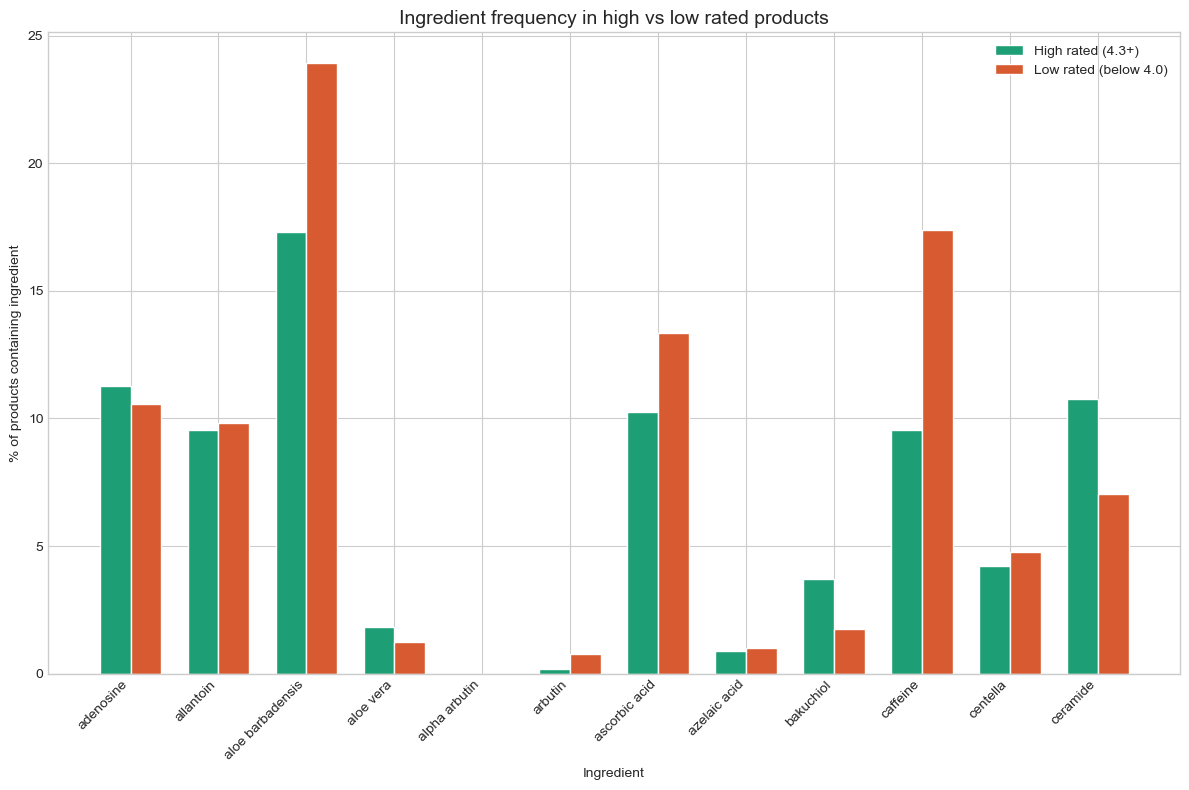

In [12]:
# Visualize ingredient frequency comparison
fig, ax = plt.subplots(figsize=(12, 8))

top_ingredients = comparison.head(12)
x = np.arange(len(top_ingredients))
width = 0.35

bars1 = ax.bar(x - width/2, top_ingredients["high_rated_pct"], 
               width, label="High rated (4.3+)", 
               color="#1D9E75", edgecolor="white")
bars2 = ax.bar(x + width/2, top_ingredients["low_rated_pct"], 
               width, label="Low rated (below 4.0)", 
               color="#D85A30", edgecolor="white")

ax.set_title("Ingredient frequency in high vs low rated products", fontsize=14)
ax.set_xlabel("Ingredient")
ax.set_ylabel("% of products containing ingredient")
ax.set_xticks(x)
ax.set_xticklabels(top_ingredients.index, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Ingredient Quality by Category
Which skincare categories have the best ingredient profiles?
Do moisturizers have better formulas than cleansers?

=== INGREDIENT QUALITY BY CATEGORY ===
    secondary_category  avg_ingredient_score  avg_good_count  avg_bad_count  avg_rating  product_count  powerhouse_pct
            Treatments                 0.138           4.277          0.369       4.304            452           0.743
              Eye Care                 0.109           5.185          0.543       4.108            184           0.935
          Moisturizers                 0.089           3.974          0.576       4.275            538           0.734
                 Masks                 0.085           3.594          0.485       4.250            165           0.697
             Cleansers                 0.084           2.797          0.449       4.314            354           0.506
          Self Tanners                 0.075           3.151          0.679       3.955             53           0.660
Lip Balms & Treatments                 0.048           2.066          0.508       4.147             61           0.344
         

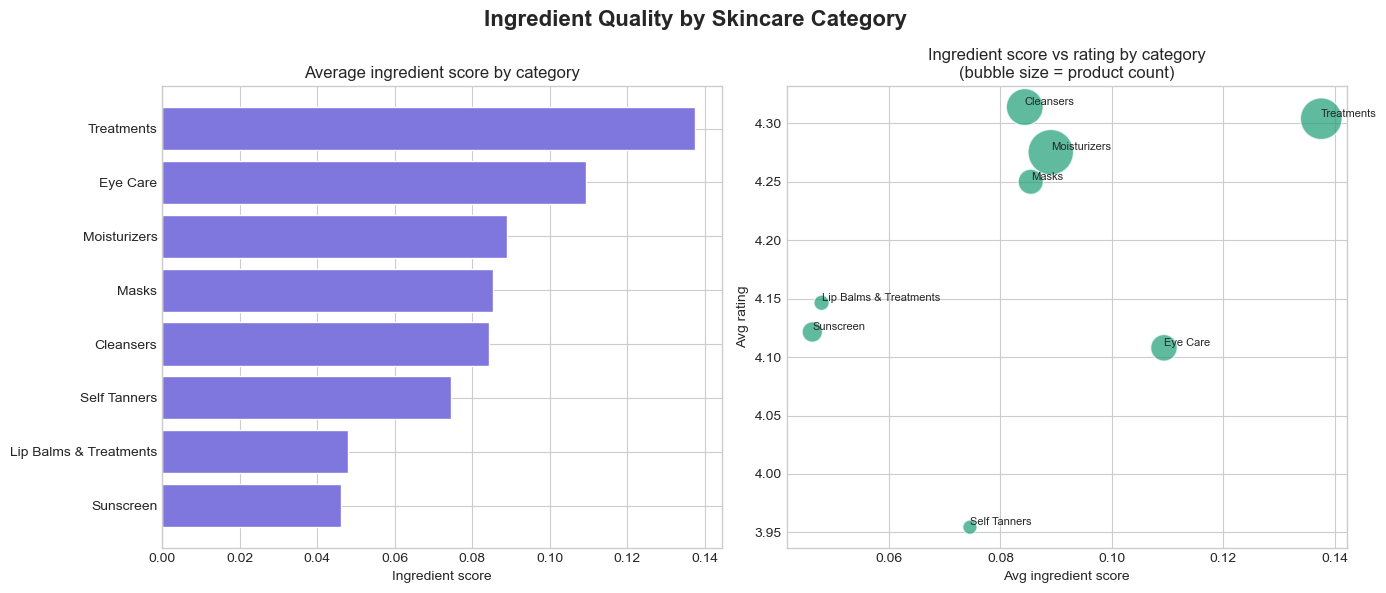

In [13]:
category_ingredients = df.groupby("secondary_category").agg(
    avg_ingredient_score=("ingredient_score", "mean"),
    avg_good_count=("good_ingredient_count", "mean"),
    avg_bad_count=("bad_ingredient_count", "mean"),
    avg_rating=("avg_rating", "mean"),
    product_count=("product_id", "count"),
    powerhouse_pct=("powerhouse_flag", "mean")
).reset_index().sort_values("avg_ingredient_score", ascending=False)

print("=== INGREDIENT QUALITY BY CATEGORY ===")
print(category_ingredients.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ingredient Quality by Skincare Category", fontsize=16, fontweight="bold")

axes[0].barh(category_ingredients["secondary_category"],
             category_ingredients["avg_ingredient_score"],
             color="#7F77DD", edgecolor="white")
axes[0].set_title("Average ingredient score by category")
axes[0].set_xlabel("Ingredient score")
axes[0].invert_yaxis()

axes[1].scatter(
    category_ingredients["avg_ingredient_score"],
    category_ingredients["avg_rating"],
    s=category_ingredients["product_count"] * 2,
    color="#1D9E75", alpha=0.7, edgecolors="white"
)
for _, row in category_ingredients.iterrows():
    axes[1].annotate(row["secondary_category"],
                    (row["avg_ingredient_score"], row["avg_rating"]),
                    fontsize=8, ha="left", va="bottom")
axes[1].set_title("Ingredient score vs rating by category\n(bubble size = product count)")
axes[1].set_xlabel("Avg ingredient score")
axes[1].set_ylabel("Avg rating")

plt.tight_layout()
plt.show()

### Ingredient Analysis Findings

**Overall ingredient-rating relationship:**
- Correlation between ingredient score and avg rating: 0.057 — essentially zero
- Powerhouse products (3+ hero ingredients) rate only 0.015 stars higher 
  than non-powerhouse products
- Conclusion: customers do not consciously rate products based on 
  what ingredients they contain

**Specific ingredient findings:**
- Ceramide is the strongest positive signal — 10.8% of high rated products 
  contain it vs 7.1% of low rated — +3.7% difference
- Bakuchiol also favors high rated products (+2.0%) — emerging hero ingredient 
  with genuine performance
- Surprising negative findings: caffeine (-7.8%), aloe barbadensis (-6.6%), 
  and ascorbic acid/vitamin C (-3.1%) are more common in LOW rated products
- This doesn't mean these are bad ingredients — it reflects that products 
  targeting specific concerns (dark circles, brightening) often disappoint 
  customers because expectations are higher for treatment products

**Category ingredient quality:**
- Treatments have the best ingredient profiles (score 0.138) and also 
  rate highest (4.30) — strongest alignment between formula and satisfaction
- Eye Care has strong ingredients (0.109) but lower ratings (4.11) — 
  customers have very high expectations for eye products that even 
  good formulas struggle to meet
- Sunscreen scores lowest on ingredients (0.046) due to chemical UV 
  filters — a limitation of our ingredient scoring methodology
- Cleansers rate highest (4.31) despite mid ingredient scores — 
  sensory experience (lather, scent, texture) drives cleanser ratings 
  more than formula composition

**Key business insight:**
- Brand perception, sensory experience, and marketing drive ratings 
  far more than ingredient quality
- This validates our ML model approach — the gap between objective 
  ingredient-based predictions and actual ratings captures real brand hype
- Ceramide is the one ingredient with clear positive rating association — 
  products containing ceramide consistently rate higher
- Eye care is the most underserved category — strong ingredients but 
  customer expectations exceed even good formulas

## 6. Top Products by Category
Ranking the best products within each skincare category based on 
a combination of avg_rating, ingredient_score, and review_count.
This gives actionable recommendations beyond just overall rankings.

In [14]:
# For each category show top 5 products by avg_rating with 20+ reviews
categories = df["secondary_category"].unique()

for category in sorted(categories):
    cat_df = df[
        (df["secondary_category"] == category) & 
        (df["review_count"] >= 20)
    ].sort_values("avg_rating", ascending=False).head(5)
    
    if len(cat_df) == 0:
        continue
        
    print(f"\n{'='*60}")
    print(f"TOP 5 — {category.upper()}")
    print(f"{'='*60}")
    print(cat_df[[
        "product_name", "brand_name", "price_usd", 
        "avg_rating", "review_count", "ingredient_score"
    ]].to_string(index=False))


TOP 5 — CLEANSERS
                                                  product_name      brand_name  price_usd  avg_rating  review_count  ingredient_score
        Pore Perfecting Liquid Exfoliator with 2% BHA + Borage    Alpyn Beauty     39.000       4.930       100.000             0.279
High Performance Face Cleanser for Clear Skin with Niacinamide Macrene Actives     85.000       4.927        55.000             0.167
                    Aquarius BHA + Blue Tansy Clarity Cleanser       Herbivore     26.000       4.927        55.000             0.097
                     Chia + Moringa Algae Enzyme Cleansing Oil            Mara     58.000       4.880       241.000             0.125
            Juneberry & Collagen Hydrating Cold Cream Cleanser    Alpyn Beauty     39.000       4.879       240.000             0.158

TOP 5 — EYE CARE
                                                    product_name                        brand_name  price_usd  avg_rating  review_count  ingredient_score
High 

## 7. Ingredient Score vs Price
Do more expensive products have better ingredients?
Or is premium pricing just marketing?

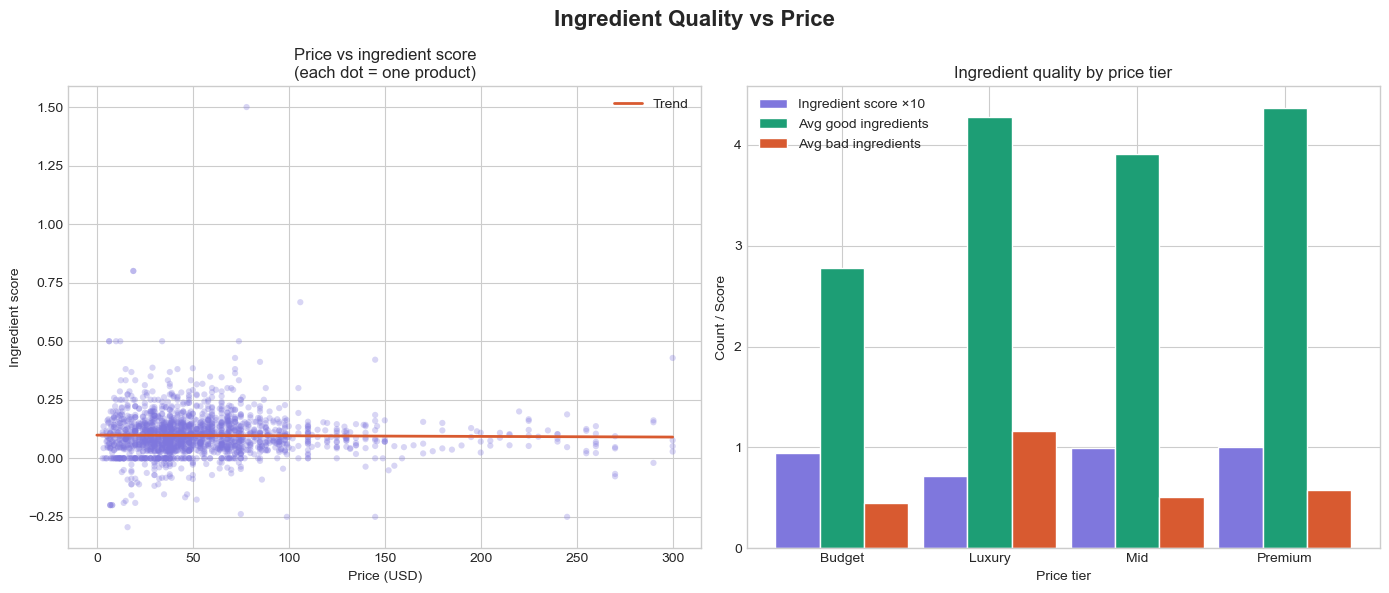

Correlation between price and ingredient score: -0.031

Ingredient score by price tier:
price_tier  avg_ingredient_score  avg_good_count  avg_bad_count
    Budget                 0.095           2.779          0.448
    Luxury                 0.072           4.275          1.163
       Mid                 0.099           3.913          0.506
   Premium                 0.100           4.366          0.574


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ingredient Quality vs Price", fontsize=16, fontweight="bold")

# Plot 1: Scatter ingredient score vs price
products_under_300 = df[df["price_usd"] <= 300]
axes[0].scatter(
    products_under_300["price_usd"],
    products_under_300["ingredient_score"],
    alpha=0.3,
    color="#7F77DD",
    edgecolors="none",
    s=20
)

z = np.polyfit(products_under_300["price_usd"].dropna(),
               products_under_300["ingredient_score"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(0, 300, 100)
axes[0].plot(x_line, p(x_line), color="#D85A30", linewidth=2, label="Trend")
axes[0].set_title("Price vs ingredient score\n(each dot = one product)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Ingredient score")
axes[0].legend()

# Plot 2: Average ingredient score by price tier
tier_ingredients = df.groupby("price_tier", observed=True).agg(
    avg_ingredient_score=("ingredient_score", "mean"),
    avg_good_count=("good_ingredient_count", "mean"),
    avg_bad_count=("bad_ingredient_count", "mean")
).reset_index()

x = np.arange(len(tier_ingredients))
width = 0.3

axes[1].bar(x - width, tier_ingredients["avg_ingredient_score"] * 10,
            width, label="Ingredient score ×10", color="#7F77DD", edgecolor="white")
axes[1].bar(x, tier_ingredients["avg_good_count"],
            width, label="Avg good ingredients", color="#1D9E75", edgecolor="white")
axes[1].bar(x + width, tier_ingredients["avg_bad_count"],
            width, label="Avg bad ingredients", color="#D85A30", edgecolor="white")

axes[1].set_title("Ingredient quality by price tier")
axes[1].set_xlabel("Price tier")
axes[1].set_ylabel("Count / Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_ingredients["price_tier"])
axes[1].legend()

plt.tight_layout()
plt.show()

# Print correlation
corr = df["price_usd"].corr(df["ingredient_score"])
print(f"Correlation between price and ingredient score: {corr:.3f}")
print(f"\nIngredient score by price tier:")
print(tier_ingredients.to_string(index=False))